# Shot Success Model

In [17]:
# Call jupyter notebook to load data

%run ./Load_NBA_Dataset.ipynb

In [18]:
# Import Libraries

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.decomposition import PCA
import sklearn.metrics as metrics

import matplotlib.pyplot as plt

## Data Prep

In [19]:
df_encoded.columns

['PERIOD',
 'LOC_X',
 'LOC_Y',
 'pointsTotal',
 'relative_margin_before',
 'shotDistance',
 'SHOT_MADE_FLAG',
 'time_remaining',
 'subType_DUNK',
 'subType_Hook',
 'subType_Jump Shot',
 'subType_Layup',
 'side_left',
 'side_right',
 'SHOT_ZONE_BASIC_Above the Break 3',
 'SHOT_ZONE_BASIC_Backcourt',
 'SHOT_ZONE_BASIC_In The Paint (Non-RA)',
 'SHOT_ZONE_BASIC_Left Corner 3',
 'SHOT_ZONE_BASIC_Mid-Range',
 'SHOT_ZONE_BASIC_Restricted Area',
 'SHOT_ZONE_BASIC_Right Corner 3',
 'SHOT_ZONE_AREA_Back Court(BC)',
 'SHOT_ZONE_AREA_Center(C)',
 'SHOT_ZONE_AREA_Left Side Center(LC)',
 'SHOT_ZONE_AREA_Left Side(L)',
 'SHOT_ZONE_AREA_Right Side Center(RC)',
 'SHOT_ZONE_AREA_Right Side(R)',
 'SHOT_ZONE_RANGE_16-24 ft.',
 'SHOT_ZONE_RANGE_24+ ft.',
 'SHOT_ZONE_RANGE_8-16 ft.',
 'SHOT_ZONE_RANGE_Back Court Shot',
 'SHOT_ZONE_RANGE_Less Than 8 ft.']

In [20]:
#
unused = [
    'PERIOD',
    'LOC_X',
    'LOC_Y',
    'relative_margin_before',
    'time_remaining',       
    'SHOT_ZONE_BASIC_Above the Break 3',
    'SHOT_ZONE_BASIC_Backcourt',
    'SHOT_ZONE_BASIC_In The Paint (Non-RA)',
    'SHOT_ZONE_BASIC_Left Corner 3',
    'SHOT_ZONE_BASIC_Mid-Range',
    'SHOT_ZONE_BASIC_Restricted Area',
    'SHOT_ZONE_BASIC_Right Corner 3',
    'SHOT_ZONE_AREA_Back Court(BC)',
    'SHOT_ZONE_AREA_Center(C)',
    'SHOT_ZONE_AREA_Left Side Center(LC)',
    'SHOT_ZONE_AREA_Left Side(L)'
]

In [21]:
# Variables to filter by (not in use)
include_variables = [
    'shotDistance',
    'LOC_X',
    'side_left'

]

In [22]:
# Split independent & dependent variables
X = df_encoded.drop('SHOT_MADE_FLAG').select(
    include_variables
)
Y = pl.Series(df_encoded.select('SHOT_MADE_FLAG')).to_numpy()

In [23]:
# Principal Component Analaysis (PCA)

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X)

print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[9.91632401e-01 8.34941278e-03 1.81862692e-05]
[54688.77250788  5018.23260148   234.20417283]


#### Split into test training data

In [24]:
# Numerical variables only
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.7)

# Numerical & categorical variables
x_train2, x_test2, y_train2, y_test2 = train_test_split(X, Y, train_size=0.7)

# Split 
# Data for linear regression (excludes categorical variables)
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(X_reduced, Y, train_size=0.7)

## Model Selection

### RidgeClassifier

Train & evaluate linear regression classifiers, which can only use continuous numeric input variables i.e. no encoded categorical


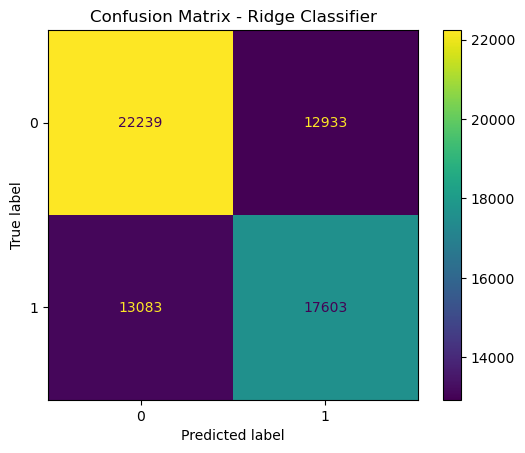

In [25]:
clf_ridge = RidgeClassifier().fit(x_train, y_train)
y_pred_ridge = clf_ridge.predict(x_test)

# Calculate & display confusion matrix
cm_ridge = metrics.confusion_matrix(y_test, y_pred_ridge)
cm_fig_ridge = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_ridge, display_labels=clf_ridge.classes_)
cm_fig_ridge.plot(values_format='d')
plt.title("Confusion Matrix - Ridge Classifier")
plt.show()

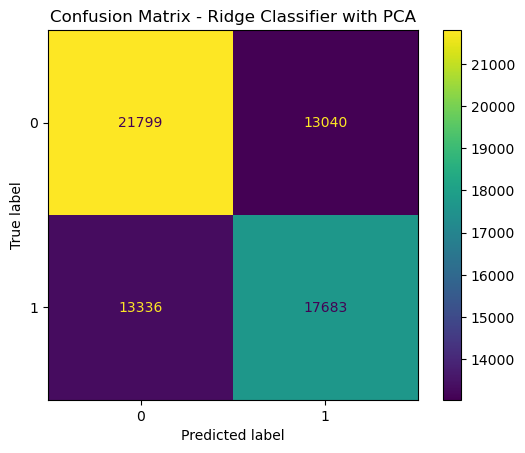

Ridge Classifier ROC AUC: 0.639443270178577


In [26]:
clf_ridge_pca = RidgeClassifier().fit(x_train_pca, y_train_pca)
y_pred_ridge_pca = clf_ridge_pca.predict(x_test_pca)

# Calculate & display confusion matrix
cm_ridge_pca = metrics.confusion_matrix(y_test_pca, y_pred_ridge_pca)
cm_fig_ridge_pca = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_ridge_pca, display_labels=clf_ridge_pca.classes_)
cm_fig_ridge_pca.plot(values_format='d')
plt.title("Confusion Matrix - Ridge Classifier with PCA")
plt.show()

# Calculate AUC & ROC Scores
ridge_roc_auc = metrics.roc_auc_score(y_test_pca, clf_ridge_pca.decision_function(x_test_pca))

print(f"Ridge Classifier ROC AUC: {ridge_roc_auc}")

In [27]:
# Cross Validation
score_ridge = cross_val_score(clf_ridge, X, Y, cv=10)
score_ridge

array([0.60151232, 0.60497426, 0.60611306, 0.60192229, 0.60012755,
       0.59748542, 0.60071975, 0.60153972, 0.60281523, 0.60081086])

### Logistic Regression

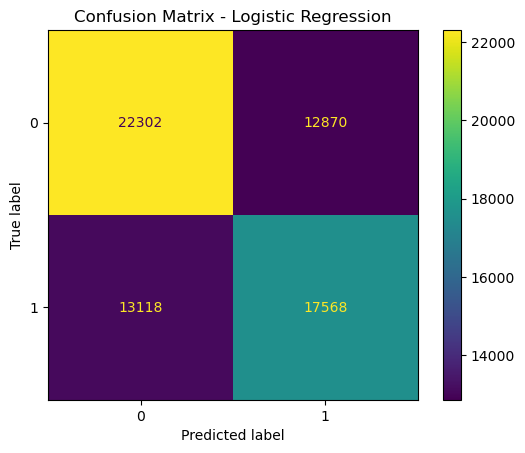

In [28]:
# Initialize and train the model
clf_log = LogisticRegression(C=10, solver='liblinear', penalty='l2').fit(x_train, y_train)
y_pred_log = clf_log.predict(x_test)

# Calculate & display confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_log)
cm_fig = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_log.classes_)
cm_fig.plot(values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


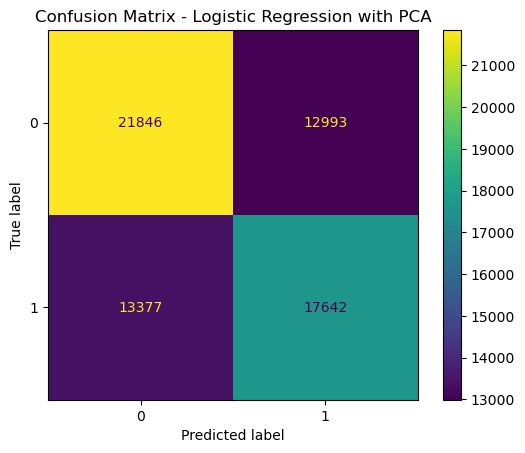

Logistic Regression ROC AUC: 0.6394312054514659


In [29]:
# Logistic regrression pca
clf_log_pca = LogisticRegression(C=10, solver='liblinear', penalty='l2').fit(x_train_pca, y_train_pca)
y_pred_log_pca = clf_log_pca.predict(x_test_pca)

# Calculate & display confusion matrix
cm_pca = metrics.confusion_matrix(y_test_pca, y_pred_log_pca)
cm_fig_pca = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=clf_log_pca.classes_)
cm_fig_pca.plot(values_format='d')
plt.title("Confusion Matrix - Logistic Regression with PCA")
plt.show()

# Calculate AUC & ROC Scores
log_roc_auc = metrics.roc_auc_score(y_test_pca, clf_log_pca.decision_function(x_test_pca))
print(f"Logistic Regression ROC AUC: {log_roc_auc}")

In [30]:
# Optimise logistic regression hyper parameters
param_grid_log1 = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

param_grid_log2 = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'penalty': ['l2']
}

clf_log2 = LogisticRegression()

# Create & train grid_search object for param grid 1
grid_search_log1 = GridSearchCV(clf_log2, param_grid_log1, cv=5, scoring='accuracy')
grid_search_log1.fit(x_train, y_train)

print("Best set of hyperparameters from grid 1: ", grid_search_log1.best_params_)
print("Best score: ", grid_search_log1.best_score_)

# Create & train grid_search object for param grid 2
grid_search_log2 = GridSearchCV(clf_log2, param_grid_log2, cv=5, scoring='accuracy')
grid_search_log2.fit(x_train, y_train)

print("Best set of hyperparameters from grid 2: ", grid_search_log2.best_params_)
print("Best score: ", grid_search_log2.best_score_)



Best set of hyperparameters from grid 1:  {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best score:  0.6006793477780423
Best set of hyperparameters from grid 2:  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best score:  0.6005166583261343


In [31]:
# Cross Validation
clf_log3 = LogisticRegressionCV(Cs=[1, 10, 100], cv=10, random_state=47).fit(X, Y)
scores_log = clf_log3.scores_
print(f"Scores: {scores_log}")

dlog_score = pd.DataFrame(scores_log.get(1)).mean()
dlog_score

Scores: {1: array([[0.60201339, 0.60201339, 0.60201339],
       [0.60483761, 0.60483761, 0.60483761],
       [0.60593085, 0.60593085, 0.60593085],
       [0.60215005, 0.60215005, 0.60215005],
       [0.60071975, 0.60071975, 0.60071975],
       [0.5978043 , 0.5978043 , 0.5978043 ],
       [0.60081086, 0.60081086, 0.60081086],
       [0.60176749, 0.60176749, 0.60176749],
       [0.60281523, 0.60281523, 0.60281523],
       [0.60099308, 0.60099308, 0.60099308]])}


0    0.601984
1    0.601984
2    0.601984
dtype: float64

In [32]:
# Cross Validate
score_log = cross_val_score(clf_log_pca, X, Y, cv=10)
score_log


array([0.60192229, 0.60492871, 0.60593085, 0.6021956 , 0.6006742 ,
       0.5978043 , 0.60081086, 0.60181305, 0.60276968, 0.60103863])

### LinearSVC


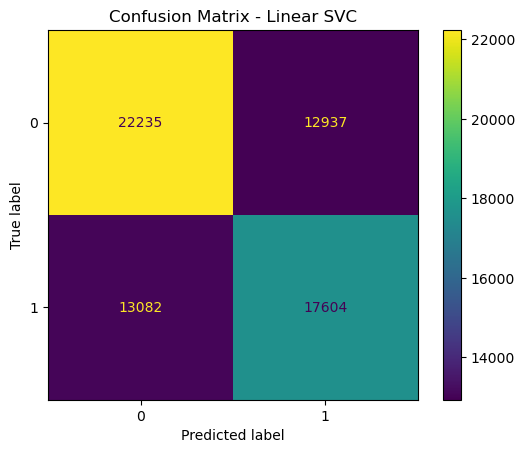

In [33]:
linear_svc = LinearSVC(max_iter=5000).fit(x_train, y_train)
y_pred_svc = linear_svc.predict(x_test)

# Calculate & display confusion matrix
cm_svc = metrics.confusion_matrix(y_test, y_pred_svc)
cm_fig_svc = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=linear_svc.classes_)
cm_fig_svc.plot(values_format='d')
plt.title("Confusion Matrix - Linear SVC")
plt.show()

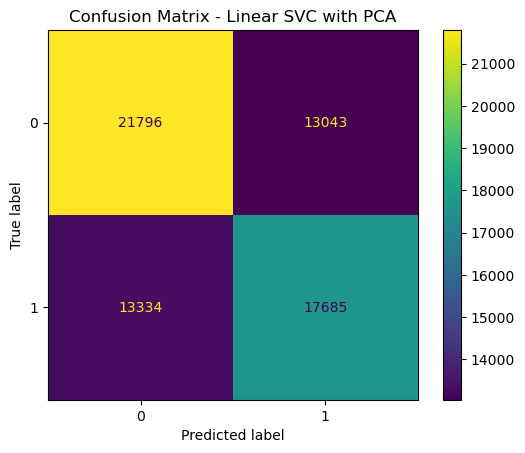

Logistic Regression ROC AUC: 0.6394422856050499


In [34]:
# With PCA
linear_svc_pca = LinearSVC(max_iter=5000).fit(x_train_pca, y_train_pca)
y_pred_svc_pca = linear_svc_pca.predict(x_test_pca)

# Calculate & display confusion matrix
cm_svc_pca = metrics.confusion_matrix(y_test_pca, y_pred_svc_pca)
cm_fig_svc_pca = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_svc_pca, display_labels=linear_svc_pca.classes_)
cm_fig_svc_pca.plot(values_format='d')
plt.title("Confusion Matrix - Linear SVC with PCA")
plt.show()

# Calculate AUC & ROC Scores
svc_roc_auc = metrics.roc_auc_score(y_test_pca, linear_svc_pca.decision_function(x_test_pca))
print(f"Logistic Regression ROC AUC: {svc_roc_auc}")

In [35]:
# Cross Validate
score_svc = cross_val_score(linear_svc, X, Y, cv=10)
score_svc

array([0.60151232, 0.60497426, 0.60606751, 0.60192229, 0.6001731 ,
       0.59743987, 0.60071975, 0.60144862, 0.60276968, 0.60076531])

### XGBoost

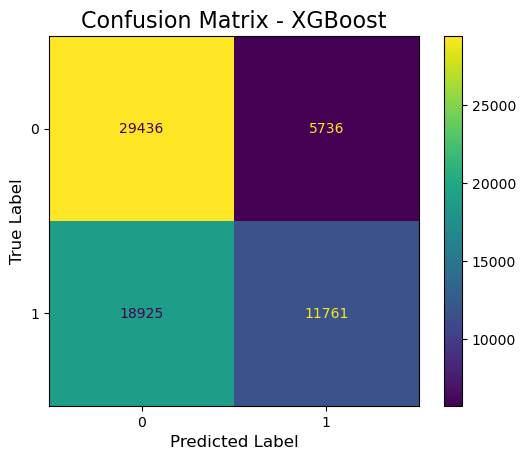

In [36]:
clf_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3).fit(x_train, y_train)
y_pred_xgb = clf_xgb.predict(x_test)

# Calculate & display confusion matrix
cm_xgb = metrics.confusion_matrix(y_test, y_pred_xgb)
cm_fig_xgb = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=clf_xgb.classes_)
cm_fig_xgb.plot(values_format='d')
plt.title("Confusion Matrix - XGBoost", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

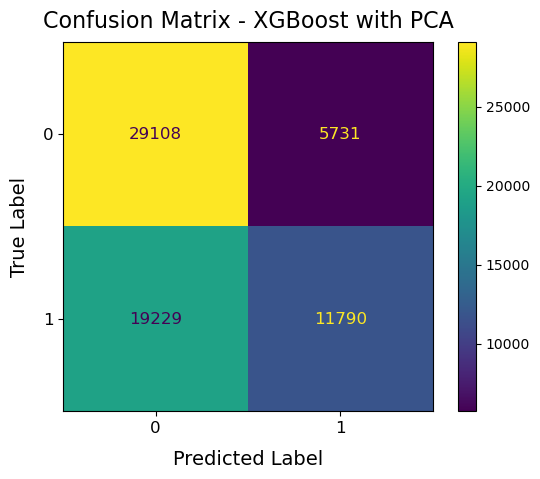

XGBoost ROC AUC: 0.6428536126428517


In [37]:
# XGBoost classifier using pca
clf_xgb_pca = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3).fit(x_train_pca, y_train_pca)
y_pred_xgb_pca = clf_xgb_pca.predict(x_test_pca)

# Calculate & display confusion matrix
cm_xgb_pca = metrics.confusion_matrix(y_test_pca, y_pred_xgb_pca)
cm_fig_xgb_pca = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_xgb_pca, display_labels=clf_xgb_pca.classes_)
cm_fig_xgb_pca.plot(values_format='d')
plt.title("Confusion Matrix - XGBoost with PCA", fontsize=16, pad=10)
plt.xlabel("Predicted Label", fontsize=14, labelpad=10)
plt.ylabel("True Label", fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adjust font size of the values inside the cells
for text in cm_fig_xgb_pca.text_.ravel():
    text.set_fontsize(12)

plt.show()

# Calculate AUC & ROC Scores
xgb_roc_auc = metrics.roc_auc_score(y_test_pca, clf_xgb_pca.predict_proba(x_test_pca)[:,1])
print(f"XGBoost ROC AUC: {xgb_roc_auc}")

In [38]:
# Optimise XGBoost hyper parameters
XGB_param_grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [2, 5, 10]
}

xgb_model = XGBClassifier()

# Create & train grid_search object
grid_search = GridSearchCV(xgb_model, XGB_param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

print("Best set of hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best score:  0.623840003552514


In [39]:
# Cross Validate
score_xgb = cross_val_score(clf_xgb_pca, X, Y, cv=10)
score_xgb

array([0.62369608, 0.62032524, 0.6291623 , 0.62018858, 0.6272777 ,
       0.62090015, 0.62513666, 0.62377004, 0.62527332, 0.62768768])

### Random Forest

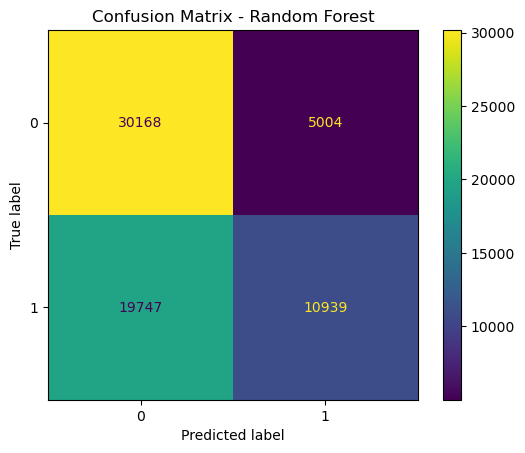

In [40]:

# Train & score classifier
clf_forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=45).fit(x_train, y_train)
y_pred_forest = clf_forest.predict(x_test)

# Calculate & display confusion matrix
cm_forest = metrics.confusion_matrix(y_test, y_pred_forest)
cm_fig_forest = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_forest, display_labels=clf_forest.classes_)
cm_fig_forest.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

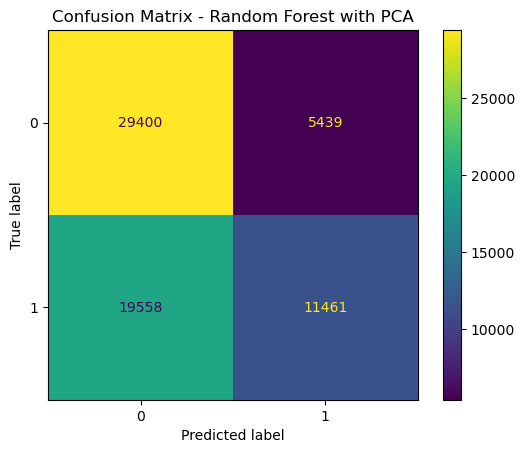

Random Forrest ROC AUC: 0.6421503694342421


In [41]:

# Train & score classifier
clf_forest_pca = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=45).fit(x_train_pca, y_train_pca)
y_pred_forest_pca = clf_forest_pca.predict(x_test_pca)

# Calculate & display confusion matrix
cm_forest_pca = metrics.confusion_matrix(y_test_pca, y_pred_forest_pca)
cm_fig_forest_pca = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_forest_pca, display_labels=clf_forest_pca.classes_)
cm_fig_forest_pca.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest with PCA")
plt.show()

# Calculate AUC & ROC Scores
rf_roc_auc = metrics.roc_auc_score(y_test_pca, clf_forest_pca.predict_proba(x_test_pca)[:,1])
print(f"Random Forrest ROC AUC: {rf_roc_auc}")

In [42]:
# Optimise Random Forest via hyper parameter tuning
param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [2, 5, 10]
}

# Perform Grid Search
grid_search_rf = GridSearchCV(clf_forest, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(x_train, y_train)

print("Best set of hyperparameters: ", grid_search_rf.best_params_)
print("Best score: ", grid_search_rf.best_score_)

Best set of hyperparameters:  {'max_depth': 5, 'n_estimators': 100}
Best score:  0.6230916233923361


In [43]:
# Cross Validate
score_rf = cross_val_score(clf_forest_pca, X, Y, cv=10)
score_rf

array([0.62283059, 0.62173735, 0.62866123, 0.61444905, 0.62632106,
       0.62039905, 0.62490889, 0.62281341, 0.62295007, 0.62358783])

### Decision Tree

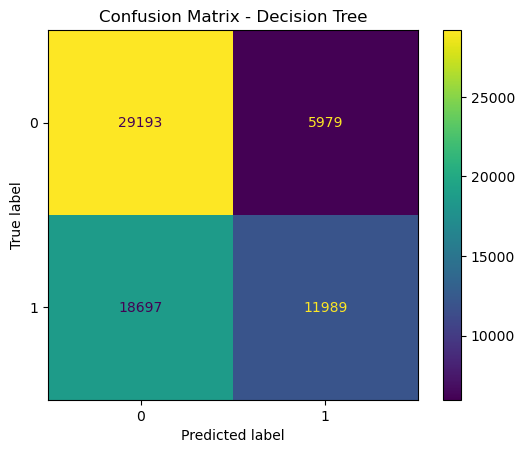

In [44]:

clf_decision = DecisionTreeClassifier(max_depth=4, min_samples_split=3, min_samples_leaf=2).fit(x_train, y_train)
y_pred_decision = clf_decision.predict(x_test)

# Calculate & display confusion matrix
cm_decision = metrics.confusion_matrix(y_test, y_pred_decision)
cm_fig_decision = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_decision, display_labels=clf_decision.classes_)
cm_fig_decision.plot(values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

c:\Users\daveb\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


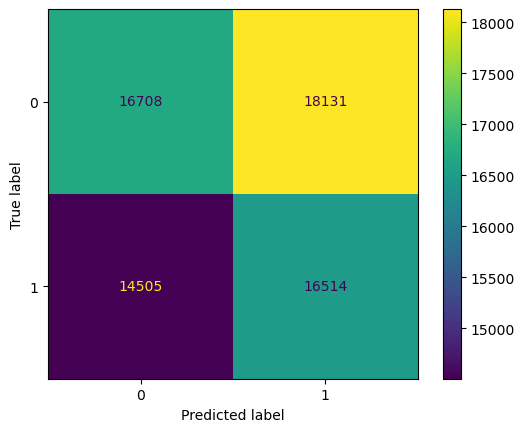

Decision Tree ROC AUC: 0.5393014921458872


c:\Users\daveb\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [45]:
# Decision tree classifer with PCA
clf_decision_pca = DecisionTreeClassifier(max_depth=4, min_samples_split=2, min_samples_leaf=2).fit(x_train, y_train)
y_pred_decision_pca = clf_decision_pca.predict(x_test_pca)

# Calculate & display confusion matrix
cm_decision_pca = metrics.confusion_matrix(y_test_pca, y_pred_decision_pca)
cm_fig_decision_pca = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_decision_pca, display_labels=clf_decision_pca.classes_)
cm_fig_decision_pca.plot(values_format='d')
plt.show()

# Calculate AUC & ROC Scores
decision_roc_auc = metrics.roc_auc_score(y_test_pca, clf_decision_pca.predict_proba(x_test_pca)[:,1])
print(f"Decision Tree ROC AUC: {decision_roc_auc}")

In [46]:
# Decision Tree Optimisation - hyper parameter turning
param_grid_dt = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search
grid_search_dt = GridSearchCV(clf_forest, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(x_train, y_train)

print("Best set of hyperparameters: ", grid_search_dt.best_params_)
print("Best score: ", grid_search_dt.best_score_)

Best set of hyperparameters:  {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best score:  0.6231176529847203


In [47]:
# Cross Validation
score_df = cross_val_score(clf_decision, X, Y, cv=10)
score_df

array([0.62324056, 0.62073521, 0.62952672, 0.62278504, 0.62673105,
       0.61989796, 0.62459001, 0.62249453, 0.62513666, 0.62791545])

### Model Evaluation

Evaluate & compare model performance 

In [48]:
model_scores = {
    "LogisticRegression": score_log,
    "RidgeClassifer": score_ridge,
    "XGBoost": score_xgb,
    "Random Forest": score_rf,
    "Decision Tree": score_df,
    "Support Vector Classifier": score_svc
}

df_scores = pd.DataFrame(model_scores)

df_mean = pd.DataFrame(df_scores.mean()).T.rename({0:'Mean Accuracy'}, axis=0)

df_scores2 = pd.concat([df_scores, df_mean])
df_scores2

,LogisticRegression,RidgeClassifer,XGBoost,Random Forest,Decision Tree,Support Vector Classifier
0,0.601922,0.601512,0.623696,0.622831,0.623241,0.601512
1,0.604929,0.604974,0.620325,0.621737,0.620735,0.604974
2,0.605931,0.606113,0.629162,0.628661,0.629527,0.606068
3,0.602196,0.601922,0.620189,0.614449,0.622785,0.601922
4,0.600674,0.600128,0.627278,0.626321,0.626731,0.600173
5,0.597804,0.597485,0.620900,0.620399,0.619898,0.597440
6,0.600811,0.600720,0.625137,0.624909,0.624590,0.600720
7,0.601813,0.601540,0.623770,0.622813,0.622495,0.601449
8,0.602770,0.602815,0.625273,0.622950,0.625137,0.602770
9,0.601039,0.600811,0.627688,0.623588,0.627915,0.600765


In [49]:
df_compare = df_mean.T.rename_axis("Algorithm", axis="columns")

model_roc_scores = {
    "LogisticRegression": [log_roc_auc],
    "RidgeClassifer": [ridge_roc_auc],
    "XGBoost": [xgb_roc_auc],
    "Random Forest": [rf_roc_auc],
    "Decision Tree": [decision_roc_auc],
    "Support Vector Classifier": [svc_roc_auc]
}

df_roc_scores = pd.DataFrame(model_roc_scores)
#df_compare = pd.concat([df_mean, df_roc_scores.rename({0:"ROC Score"})], axis=0)
df_roc_scores

,LogisticRegression,RidgeClassifer,XGBoost,Random Forest,Decision Tree,Support Vector Classifier
0,0.639431,0.639443,0.642854,0.64215,0.539301,0.639442


In [50]:
temp = df_roc_scores.T 

df_compare['AUC_ROC Score'] = temp[0].to_list()

df_compare

Algorithm,Mean Accuracy,AUC_ROC Score
LogisticRegression,0.601989,0.639431
RidgeClassifer,0.601802,0.639443
XGBoost,0.624342,0.642854
Random Forest,0.622866,0.642150
Decision Tree,0.624305,0.539301
Support Vector Classifier,0.601779,0.639442


In [51]:
df_mean_t

NameError: name 'df_mean_t' is not defined

c:\Users\daveb\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


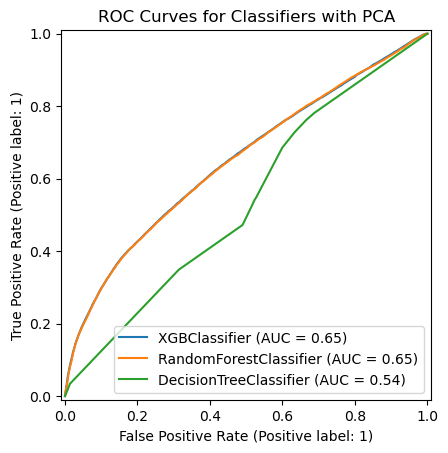

In [ ]:
# Display the AUC & ROC scores
fig_roc, ax_roc = plt.subplots()

xgb_disp = metrics.RocCurveDisplay.from_estimator(clf_xgb_pca, x_test_pca, y_test_pca, ax=ax_roc)
rf_disp = metrics.RocCurveDisplay.from_estimator(clf_forest_pca, x_test_pca, y_test_pca, ax=ax_roc)
decision_disp = metrics.RocCurveDisplay.from_estimator(clf_decision_pca, x_test_pca, y_test_pca, ax=ax_roc)
plt.title("ROC Curves for Classifiers with PCA", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14, labelpad=10)
plt.ylabel("True Positive Rate", fontsize=14, labelpad=10)
plt.show()
